# **Deliverable 5: Nuclear Medicine, SPECT, and PET**

---

## Overview

This deliverable covers key concepts from **Lectures 29–34**. The goal is to connect nuclear decay, radiopharmaceutical design, gamma-camera and SPECT system behavior, and the core physics behind PET. The final section briefly extends those ideas to hybrid imaging and clinical decision-making.

Upon successful completion, you will be able to:
1. **Apply** radioactive decay, effective half-life, and counting-statistics ideas to basic nuclear medicine calculations.
2. **Explain** how radiopharmaceutical choice, gamma-camera design, collimation, and energy windowing affect image quality.
3. **Compare** planar imaging, SPECT, and PET in terms of acquisition, reconstruction, corrections, and clinical use.
4. **Implement** compact computational models for decay/counting behavior and PET reconstruction.
5. **Evaluate** when hybrid imaging adds value and justify modality choices for selected clinical scenarios.

---

# Part 1: Radioactivity, Radiotracers, and Counting Fundamentals

## Key Concepts

**Activity and Decay:**
- $A(t)=A_0 e^{-\lambda t}$, where $\lambda=\ln 2 / T_{1/2}$
- After one half-life, activity falls to 50% of its original value
- Short half-life lowers long-term dose but can reduce available counts if imaging is delayed

**Physical, Biological, and Effective Half-Life:**
- Physical half-life: radioactive decay only
- Biological half-life: physiologic clearance only
- Effective half-life: $\frac{1}{T_{eff}}=\frac{1}{T_p}+\frac{1}{T_b}$
- Effective half-life determines how quickly signal availability drops in patients

**Tracer Principle and Radiopharmaceutical Design:**
- The tracer should follow the biology of interest without perturbing it substantially
- Good tracers balance targeting, photon yield, acceptable dose, and practical production/logistics
- Tc-99m is widely used because of its 140 keV gamma emission and convenient 6 h half-life

**Counting Statistics:**
- Nuclear medicine data are count-limited and approximately Poisson distributed
- If counts = $N$, then standard deviation is about $\sqrt{N}$
- Relative noise decreases as counts increase, but higher counts usually require more time or more administered activity

## 1.1 Decay, Effective Half-Life, and Radiotracer Selection

### **Questions 1**
A patient is injected with $740\ \mathrm{MBq}$ of Tc-99m, which has a physical half-life of 6 h.

- a) Compute the remaining activity after 3 h, 6 h, and 18 h.

$$
A(t)=A_0\left(\frac12\right)^{t/T_{1/2}}
$$

$$
A_0=740\ \mathrm{MBq}, \qquad T_{1/2}=6\ \mathrm{h}
$$

After 3 h:

$$
A(3)=740\left(\frac12\right)^{3/6}
=740\left(\frac12\right)^{1/2}
\approx 740(0.707)
\approx 523\ \mathrm{MBq}
$$

After 6 h:

$$
A(6)=740\left(\frac12\right)^{6/6}
=740\left(\frac12\right)
=370\ \mathrm{MBq}
$$

After 18 h:

$$
A(18)=740\left(\frac12\right)^{18/6}
=740\left(\frac12\right)^3
=740\left(\frac18\right)
=92.5\ \mathrm{MBq}
$$

$$
\boxed{A(3)\approx 523\ \mathrm{MBq}}, \qquad
\boxed{A(6)=370\ \mathrm{MBq}}, \qquad
\boxed{A(18)=92.5\ \mathrm{MBq}}
$$

- b) If the biologic half-life of the tracer in the target organ is 12 h, compute the effective half-life.

$$
\frac{1}{T_{\mathrm{eff}}}=\frac{1}{T_p}+\frac{1}{T_b}
$$

$$
T_p=6\ \mathrm{h}, \qquad T_b=12\ \mathrm{h}
$$

$$
\frac{1}{T_{\mathrm{eff}}}=\frac{1}{6}+\frac{1}{12}
=\frac{2}{12}+\frac{1}{12}
=\frac{3}{12}
=\frac{1}{4}
$$

$$
\boxed{T_{\mathrm{eff}}=4\ \mathrm{h}}
$$

- c) Using your effective half-life, estimate the remaining activity after 3 h and briefly explain why effective half-life matters more clinically than physical half-life alone.

$$
A(t)=A_0\left(\frac12\right)^{t/T_{\mathrm{eff}}}
$$

$$
A_0=740\ \mathrm{MBq}, \qquad T_{\mathrm{eff}}=4\ \mathrm{h}
$$

$$
A(3)=740\left(\frac12\right)^{3/4}
$$

$$
\left(\frac12\right)^{3/4}\approx 0.595
$$

$$
A(3)\approx 740(0.595)\approx 440\ \mathrm{MBq}
$$

$$
\boxed{A(3)\approx 440\ \mathrm{MBq}}
$$

Effective half-life matters more clinically because it accounts for both radioactive decay and biologic clearance, so it better reflects how quickly usable signal actually decreases in the body.

---

### **Questions 2**
You are choosing between two diagnostic tracers for the same biologic target.

1. Tracer A: 140 keV gamma emission, 6 h half-life, generator produced, modest target uptake  
2. Tracer B: high-energy beta emission, 3 day half-life, excellent target uptake

- a) Which tracer is better suited to routine diagnostic imaging, and why?

Tracer A is better suited for routine diagnostic imaging.

- $140\ \mathrm{keV}$ gamma photons are ideal for detection with a gamma camera  
- A 6 h half-life is long enough for imaging but short enough to limit dose  
- Generator production makes it practical for routine use  

Tracer B is less suitable because beta emission mainly increases dose and a 3 day half-life is unnecessarily long.

$$
\boxed{\text{Tracer A is the better diagnostic choice}}
$$

- b) Identify at least three characteristics of an ideal diagnostic radiopharmaceutical.

    - Emits gamma photons with suitable energy for detection  
    - Has a half-life that balances imaging time and patient dose  
    - Shows high uptake in the target tissue  
    - Has low background uptake  


- c) Explain the tracer principle and why it is central to nuclear medicine.

The tracer principle means the radiopharmaceutical follows the biologic process of interest without significantly altering it.

This is central to nuclear medicine because it allows imaging of true physiologic and molecular processes. The tracer acts as a detectable label, so what is observed reflects real function rather than a disturbed system.

## 1.2 Decay and Count-Statistics Simulation

### **Coding Exercise 1**
Build a compact simulation that connects tracer decay to count-limited image quality.

Tasks:
1. Simulate physical decay and effective decay for at least one tracer over a 24 h period.
2. Plot activity versus time and mark a plausible imaging time window.
3. Simulate Poisson-distributed count measurements at two or three expected count levels.
4. Compare the mean and variance of your simulated counts to the Poisson expectation.
5. Briefly explain how count level, acquisition time, and administered activity trade off against image noise.

=== Coding Exercise 1: Decay and Count Statistics ===
Physical half-life: 6.00 h
Biological half-life: 12.00 h
Effective half-life: 4.00 h


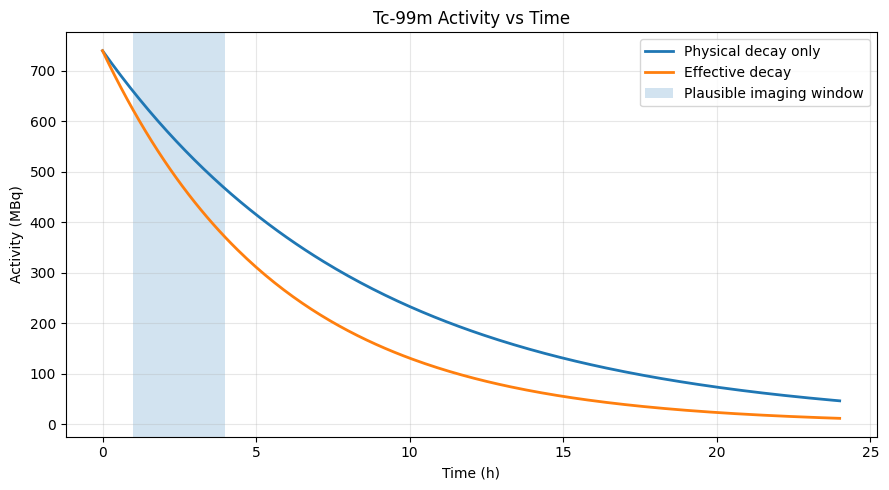


Poisson count simulation results
------------------------------------------------------------
  Expected     Sample Mean    Sample Variance  Poisson Expectation
------------------------------------------------------------
       100           99.86             100.83               100.00
      1000         1000.12            1008.84              1000.00
     10000         9995.81            9346.40             10000.00


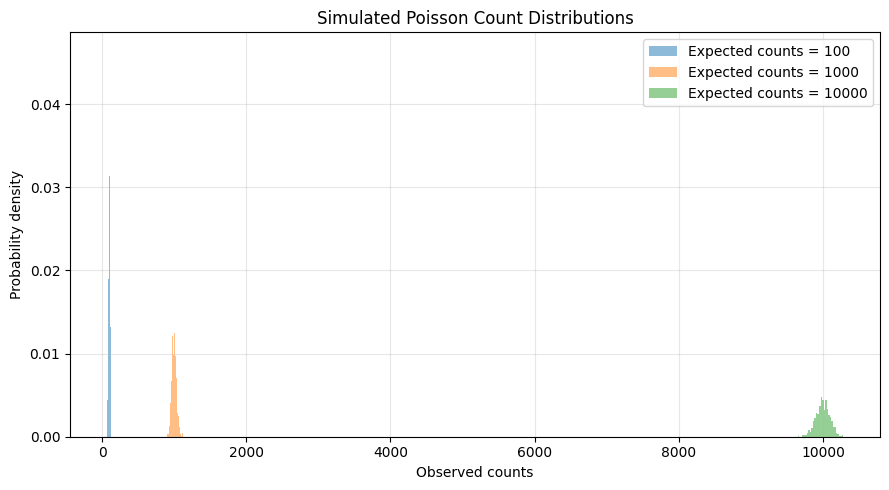


Relative noise estimates
----------------------------------------
   Expected Counts    sqrt(N)   Relative Noise ~ 1/sqrt(N)
----------------------------------------
               100      10.00                       0.1000
              1000      31.62                       0.0316
             10000     100.00                       0.0100

Interpretation:
As count level increases, the standard deviation grows approximately as sqrt(N), but the relative noise decreases approximately as 1/sqrt(N).
This means higher counts produce less noisy images. Higher counts can be achieved by increasing acquisition time, increasing administered activity, or imaging earlier when more activity remains.
The trade-off is that longer acquisition times can increase motion risk and reduce throughput, while higher administered activity increases radiation dose. In practice, image quality is balanced against patient dose and scan efficiency.


In [2]:
print("=== Coding Exercise 1: Decay and Count Statistics ===")

import matplotlib.pyplot as plt
import numpy as np

# Example teaching values for this exercise (Tc-99m)
initial_activity_mbq = 740.0
physical_half_life_hours = 6.0
biological_half_life_hours = 12.0
hours = np.linspace(0.0, 24.0, 241)
num_trials = 1000 # repeated Poisson samples for estimating mean and variance

# TODO 1: Implement a function to compute decay constant from half-life.
def decay_constant(half_life_hours):
    return np.log(2) / half_life_hours

# TODO 2: Implement a function that returns activity vs time for exponential decay.
def activity_vs_time(initial_activity, half_life_hours, time_hours):
    lam = decay_constant(half_life_hours)
    return initial_activity * np.exp(-lam * time_hours)

# TODO 3: Implement effective half-life and compute it for this tracer.
def effective_half_life(physical_half_life, biological_half_life):
    return 1.0 / ((1.0 / physical_half_life) + (1.0 / biological_half_life))

effective_half_life_hours = effective_half_life(
    physical_half_life_hours,
    biological_half_life_hours
)

physical_activity = activity_vs_time(
    initial_activity_mbq,
    physical_half_life_hours,
    hours
)

effective_activity = activity_vs_time(
    initial_activity_mbq,
    effective_half_life_hours,
    hours
)

print(f"Physical half-life: {physical_half_life_hours:.2f} h")
print(f"Biological half-life: {biological_half_life_hours:.2f} h")
print(f"Effective half-life: {effective_half_life_hours:.2f} h")

# TODO 4: Plot physical-decay and effective-decay activity curves over 24 h. Mark a plausible imaging time window on the plot.
plt.figure(figsize=(9, 5))
plt.plot(hours, physical_activity, label="Physical decay only", linewidth=2)
plt.plot(hours, effective_activity, label="Effective decay", linewidth=2)

# Example plausible imaging window for Tc-99m
imaging_start = 1.0
imaging_end = 4.0
plt.axvspan(imaging_start, imaging_end, alpha=0.2, label="Plausible imaging window")

plt.xlabel("Time (h)")
plt.ylabel("Activity (MBq)")
plt.title("Tc-99m Activity vs Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TODO 5: Simulate Poisson-distributed counts at >=2 expected count levels using repeated trials.
expected_counts = [100, 1000, 10000]
rng = np.random.default_rng(42)

simulated_counts = {}
for lam in expected_counts:
    simulated_counts[lam] = rng.poisson(lam=lam, size=num_trials)

# TODO 6: Compare sample mean/variance to the Poisson expectation and interpret.
print("\nPoisson count simulation results")
print("-" * 60)
print(f"{'Expected':>10} {'Sample Mean':>15} {'Sample Variance':>18} {'Poisson Expectation':>20}")
print("-" * 60)

for lam in expected_counts:
    samples = simulated_counts[lam]
    sample_mean = np.mean(samples)
    sample_variance = np.var(samples, ddof=1)
    print(f"{lam:>10.0f} {sample_mean:>15.2f} {sample_variance:>18.2f} {lam:>20.2f}")

# Visualize count distributions
plt.figure(figsize=(9, 5))
for lam in expected_counts:
    plt.hist(simulated_counts[lam], bins=30, alpha=0.5, density=True, label=f"Expected counts = {lam}")
plt.xlabel("Observed counts")
plt.ylabel("Probability density")
plt.title("Simulated Poisson Count Distributions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Relative noise demonstration
print("\nRelative noise estimates")
print("-" * 40)
print(f"{'Expected Counts':>18} {'sqrt(N)':>10} {'Relative Noise ~ 1/sqrt(N)':>28}")
print("-" * 40)
for lam in expected_counts:
    sigma = np.sqrt(lam)
    relative_noise = sigma / lam
    print(f"{lam:>18.0f} {sigma:>10.2f} {relative_noise:>28.4f}")

# TODO 7: Briefly explain how count level, acquisition time, and administered activity trade off against image noise.
print("\nInterpretation:")
print(
    "As count level increases, the standard deviation grows approximately as sqrt(N), "
    "but the relative noise decreases approximately as 1/sqrt(N)."
)
print(
    "This means higher counts produce less noisy images. Higher counts can be achieved by "
    "increasing acquisition time, increasing administered activity, or imaging earlier when "
    "more activity remains."
)
print(
    "The trade-off is that longer acquisition times can increase motion risk and reduce throughput, "
    "while higher administered activity increases radiation dose. In practice, image quality is "
    "balanced against patient dose and scan efficiency."
)

## 1.3 Gamma-Camera Foundations and Detector Statistics

### **Questions 3**
Explain the role of each of the following components in an Anger gamma camera:

- a) Collimator

The collimator is a lead device with many holes that only allows gamma photons traveling in certain directions to reach the detector. Its main role is to provide spatial information, because the detector itself cannot determine the original direction of the photon. By blocking most off-angle photons, the collimator helps preserve where the photon came from in the patient.

- b) NaI(Tl) scintillation crystal

The NaI(Tl) scintillation crystal absorbs incoming gamma photons and converts their energy into small flashes of visible light. The amount of light produced is approximately proportional to the energy deposited by the photon, which makes it possible to estimate photon energy.

- c) Photomultiplier tubes

Photomultiplier tubes detect the light produced in the scintillation crystal and convert it into electrical signals. Because several photomultiplier tubes receive part of the same light flash, the distribution of signal amplitudes across the tubes can be used to estimate the location of the interaction in the crystal. They also contribute to measurement of the pulse height, which is related to photon energy.

- d) Pulse-height analyzer

The pulse-height analyzer checks the size of the electrical pulse, which corresponds to the detected photon energy. It accepts events within a selected energy window around the photopeak and rejects many events with lower detected energy, which are often scattered photons.

Then explain how these components work together to localize a gamma interaction and reject many scattered photons.

A gamma photon first passes through the collimator, which restricts detection mainly to photons traveling along acceptable paths. If the photon reaches the detector and is absorbed in the NaI(Tl) crystal, it produces a flash of light. This light spreads to nearby photomultiplier tubes, which convert it into electrical signals. The relative signal strengths across the tubes are used to estimate the interaction position, while the total pulse height provides an estimate of photon energy. The pulse-height analyzer then accepts events within the chosen energy window and rejects many lower-energy scattered photons. In this way, the camera can both localize where the interaction occurred and improve image quality by excluding many scattered events.

---

### **Questions 4**
A planar study produces 40,000 counts in Region A and 22,500 counts in Region B.

- a) Estimate the standard deviation in each region using Poisson statistics.

For Poisson statistics,

$$
\sigma \approx \sqrt{N}
$$

For Region A:

$$
\sigma_A \approx \sqrt{40000} = 200
$$

For Region B:

$$
\sigma_B \approx \sqrt{22500} = 150
$$

So,

$$
\boxed{\sigma_A \approx 200}, \qquad \boxed{\sigma_B \approx 150}
$$

- b) Which region has lower relative noise, and why?

Relative noise is approximately

$$
\frac{\sigma}{N} \approx \frac{\sqrt{N}}{N} = \frac{1}{\sqrt{N}}
$$

For Region A:

$$
\frac{\sigma_A}{N_A} = \frac{200}{40000} = 0.005 = 0.5\%
$$

For Region B:

$$
\frac{\sigma_B}{N_B} = \frac{150}{22500} \approx 0.00667 = 0.667\%
$$

Region A has lower relative noise because it has more total counts. Since relative noise decreases as count level increases, the higher-count region appears less noisy.

- c) If you double acquisition time, how do the counts, standard deviation, and relative noise change approximately?

If the count rate stays constant, doubling acquisition time approximately doubles the counts:

$$
N_{\text{new}} \approx 2N
$$

The new standard deviation becomes

$$
\sigma_{\text{new}} \approx \sqrt{2N} = \sqrt{2}\sqrt{N}
$$

So the standard deviation increases by a factor of

$$
\sqrt{2} \approx 1.41
$$

The new relative noise becomes

$$
\frac{\sigma_{\text{new}}}{N_{\text{new}}}
\approx
\frac{\sqrt{2N}}{2N}
=
\frac{1}{\sqrt{2}}\cdot\frac{1}{\sqrt{N}}
$$

So relative noise decreases by a factor of

$$
\frac{1}{\sqrt{2}} \approx 0.71
$$

This means:

- counts increase by a factor of $2$
- standard deviation increases by a factor of $\sqrt{2}$
- relative noise decreases by a factor of $1/\sqrt{2}$

- d) Give one practical reason why simply increasing scan time is not always the best solution.

A longer scan time increases the chance of patient motion, which can blur the image and reduce image quality. It can also make the scan less comfortable and reduce clinical throughput.

---

# Part 2: Gamma Camera Imaging, SPECT, and Image Corrections

## Key Concepts

**Collimation and Resolution-Sensitivity Trade-off:**
- Better collimation improves spatial resolution but rejects more photons
- Higher sensitivity improves count collection but usually worsens spatial resolution
- Design choices depend on organ size, motion, and required scan time

**Planar Imaging vs SPECT:**
- Planar imaging projects 3D tracer distribution onto 2D detector space
- SPECT acquires many angular projections and reconstructs tomographic slices
- Reconstruction may use filtered backprojection or iterative methods such as OSEM

**Image Degrading Effects:**
- Attenuation reduces counts from deeper structures
- Scatter introduces mispositioned events and lowers contrast
- Motion and center-of-rotation error can create severe reconstruction artifacts

**Correction Strategies:**
- Energy windowing helps reject scatter
- Attenuation correction may be approximate or CT-based
- Quality control is essential because system calibration errors propagate into reconstructed images

# Part 2: Gamma Camera Imaging, SPECT, and Image Corrections

## 2.1 SPECT System Design and Reconstruction Choices

### **Questions 5**
You are designing a SPECT study for a small organ where fine detail matters, but the patient cannot tolerate a long scan.

- a) Explain the trade-off between collimator spatial resolution and sensitivity.

Collimator design involves a trade-off between spatial resolution and sensitivity. High-resolution collimators use smaller holes and thicker septa, which improves spatial resolution by better restricting photon direction. However, this also blocks more photons, reducing sensitivity and total counts. High-sensitivity collimators allow more photons to reach the detector, increasing count statistics, but they accept a wider range of angles, which reduces spatial resolution and image sharpness.

- b) Would you prioritize a high-resolution or high-sensitivity collimator first in this case? Defend your choice.

Since fine detail in a small organ is important, a high-resolution collimator would be prioritized. Even though scan time is limited and sensitivity is lower, preserving spatial detail is critical for accurately visualizing small structures. A balance may still be needed, but resolution is the more limiting factor for this task.

- c) How does angular sampling in SPECT improve on planar imaging?

In planar imaging, the 3D distribution of tracer activity is projected onto a 2D image, causing overlap of structures. In SPECT, images are acquired from multiple angles around the patient. These projections are then reconstructed into cross-sectional slices, allowing separation of overlapping structures and improved depth localization. This provides true 3D information rather than a single projection.

- d) Compare filtered backprojection and iterative reconstruction in terms of speed, noise behavior, and modeling flexibility.

Filtered backprojection is computationally fast and simple, but it tends to amplify noise and does not model physical effects like attenuation or scatter well. Iterative reconstruction is slower because it repeatedly refines the image estimate, but it produces better noise characteristics and can incorporate models of system physics, such as attenuation, scatter, and detector response. This makes iterative methods more flexible and often more accurate in clinical imaging.

---

### **Questions 6**
A myocardial SPECT study shows reduced counts in the inferior wall.

- a) Give two possible explanations other than true hypoperfusion.

Reduced counts in the inferior wall can be caused by attenuation from overlying structures, such as the diaphragm or abdominal tissue. Another possible explanation is patient motion during acquisition, which can create artifacts and distort the reconstructed image.

- b) Explain why attenuation correction can help, and state one limitation of approximate attenuation correction methods.

Attenuation correction compensates for the loss of photons as they pass through tissue, helping to restore counts from deeper regions and improve image uniformity. This can make areas that appear falsely reduced due to attenuation look more accurate.

A limitation of approximate attenuation correction methods is that they assume a simplified or uniform attenuation map, which may not reflect actual patient anatomy. This can lead to incomplete or inaccurate correction.

- c) How does CT-based attenuation correction improve SPECT/CT?

CT-based attenuation correction uses a patient-specific attenuation map derived from CT imaging. This provides more accurate information about tissue densities and spatial variation in attenuation, leading to improved correction of photon loss and better image accuracy compared to approximate methods.

- d) Name two routine quality-control checks that help prevent reconstruction artifacts.

One important quality-control check is center-of-rotation calibration, which ensures that the camera rotates accurately around the correct axis. Another is uniformity calibration, which checks that the detector response is consistent across the field of view. These help prevent artifacts from misalignment or detector non-uniformity.

---

# Part 3: PET Physics and Imaging Systems

## Key Concepts

**Positron Emission and Annihilation:**
- β⁺ emitters produce positrons that travel a short distance before annihilating with an electron
- Annihilation produces two 511 keV photons at ~180° — the basis for electronic coincidence detection
- Positron range varies by radionuclide: F-18 has ~0.6 mm mean range (best resolution); Rb-82 ~5.9 mm
- Non-collinearity (~0.5°) and detector size set fundamental resolution limits of ~4–6 mm for clinical PET

**Common PET Radionuclides:**
- F-18 (110 min), C-11 (20 min), N-13 (10 min), O-15 (2 min), Ga-68 (68 min), Rb-82 (1.2 min)
- Most require cyclotron production; Ga-68 and Rb-82 come from generators
- Short half-life determines logistics: C-11/O-15 require on-site cyclotron; F-18 can be shipped regionally
- F-18 FDG dominates clinically because glucose uptake is elevated in cancer, infection, and brain disorders

**Coincidence Detection:**
- True coincidence: both photons from a single annihilation detected within the timing window
- Scattered coincidence: one photon Compton-deflected — event mislocalized, degrades contrast
- Random coincidence: two photons from different annihilations detected together — adds uniform background
- Electronic collimation replaces mechanical collimation → sensitivity typically 10–50× higher than SPECT

**PET Detector Materials and TOF:**
- BGO: high stopping power but slow scintillation decay (~300 ns) — very poor TOF performance
- LSO/LYSO: fast decay (~40 ns), good light yield, enables time-of-flight PET
- TOF localization: $\Delta x = c \Delta t / 2$; better timing narrows the annihilation-point uncertainty along each LOR
- TOF advantage is largest in heavy patients because background-to-signal ratio is worst there

# Part 3: PET Physics and Imaging Systems

## 3.1 PET Physics: Coincidences, Detectors, and Radionuclides

### **Questions 7**

- a) Distinguish true, scattered, and random coincidences in PET. For each type, describe one way it is corrected or minimized in practice.

True coincidences occur when both 511 keV photons from the same annihilation event are detected within the coincidence timing window. These events are correctly localized along the line of response and contribute useful signal.

Scattered coincidences occur when at least one photon undergoes Compton scattering before detection. This changes its direction and causes mislocalization, reducing image contrast. These are minimized using energy windowing, since scattered photons typically have lower detected energy.

Random coincidences occur when two unrelated photons from different annihilation events are detected within the timing window and falsely paired. These add uniform background noise. They are reduced by using narrow coincidence timing windows and are corrected using delayed coincidence subtraction methods.

- b) Explain why PET achieves higher sensitivity than SPECT. Then name the two main physics factors that set a lower bound on PET spatial resolution regardless of detector size.

PET achieves higher sensitivity than SPECT because it uses electronic collimation instead of mechanical collimation. In PET, detection relies on coincident photons traveling in opposite directions, so many more photons are accepted compared to SPECT, where a collimator physically blocks most photons.

The two main physics factors that limit PET spatial resolution are:

- Positron range before annihilation, which causes displacement between emission and annihilation location  
- Non-collinearity of annihilation photons, which introduces angular deviation and positional uncertainty  

- c) A PET system has a coincidence timing resolution of $\Delta t = 400\ \mathrm{ps}$. Calculate the TOF localization uncertainty $\Delta x$. How would this change with a next-generation system at $\Delta t = 200\ \mathrm{ps}$?

$$
\Delta x = \frac{c \Delta t}{2}
$$

Using

$$
c = 3 \times 10^8\ \mathrm{m/s}, \qquad \Delta t = 400 \times 10^{-12}\ \mathrm{s}
$$

$$
\Delta x = \frac{(3 \times 10^8)(400 \times 10^{-12})}{2}
= \frac{(3 \times 10^8)(4 \times 10^{-10})}{2}
= \frac{1.2 \times 10^{-1}}{2}
= 0.06\ \mathrm{m}
$$

$$
\boxed{\Delta x \approx 6\ \mathrm{cm}}
$$

For $\Delta t = 200\ \mathrm{ps}$:

$$
\Delta x = \frac{(3 \times 10^8)(200 \times 10^{-12})}{2}
= \frac{(3 \times 10^8)(2 \times 10^{-10})}{2}
= \frac{6 \times 10^{-2}}{2}
= 0.03\ \mathrm{m}
$$

$$
\boxed{\Delta x \approx 3\ \mathrm{cm}}
$$

This shows that improving timing resolution by a factor of 2 halves the spatial uncertainty along the line of response.

---

### **Questions 8**

A lesion at imaging time has a measured concentration of $12\ \mathrm{kBq/mL}$. The decay-corrected injected activity is $300\ \mathrm{MBq}$ and patient mass is $70\ \mathrm{kg}$.

- a) Compute the SUV using body-mass normalization. Show your working.

$$
\mathrm{SUV} = \frac{\text{activity concentration}}{\text{injected activity} / \text{body mass}}
$$

Convert units:

$$
12\ \mathrm{kBq/mL} = 12000\ \mathrm{Bq/mL}
$$

$$
300\ \mathrm{MBq} = 3 \times 10^8\ \mathrm{Bq}
$$

$$
70\ \mathrm{kg} = 70000\ \mathrm{g}
$$

$$
\mathrm{SUV} = \frac{12000}{(3 \times 10^8) / 70000}
= \frac{12000}{4285.7}
\approx 2.8
$$

$$
\boxed{\mathrm{SUV} \approx 2.8}
$$

- b) Explain two reasons why direct SUV comparison between different institutions or scanners requires standardization.

SUV depends on accurate calibration between the PET scanner and dose calibrator, so differences in calibration can affect values. It is also sensitive to imaging protocol factors such as uptake time, reconstruction method, and attenuation correction. Variability in these factors between sites can lead to inconsistent SUV measurements.

- c) A clinical site has no on-site cyclotron. Compare F-18 FDG and Rb-82 for a cardiac PET study at this site. For each tracer, state the half-life, production method, approximate positron range, and one practical implication for the imaging workflow.

F-18 FDG has a half-life of about $110\ \mathrm{min}$ and is produced in a cyclotron. It has a short positron range of about $0.6\ \mathrm{mm}$, which supports high spatial resolution. Because of its relatively long half-life, it can be produced off-site and transported to imaging centers, making it practical for facilities without a cyclotron.

Rb-82 has a very short half-life of about $1.2\ \mathrm{min}$ and is produced from a generator system. It has a much longer positron range of about $5.9\ \mathrm{mm}$, which reduces spatial resolution. Its short half-life requires on-site generator use and rapid imaging workflows, as the tracer decays very quickly after administration.

## 3.2 PET Reconstruction from a Synthetic Phantom

### **Coding Exercise 2**
Implement a compact PET-style reconstruction workflow using a **synthetic phantom**.

### Tasks
1. Build a simple 2D phantom with uniform background uptake and at least two hot regions (different sizes and/or intensities).
2. Generate a parallel-beam sinogram over multiple projection angles. (Hint: use a Radon transform.)
3. Add Poisson noise to simulate realistic PET acquisition.
5. Reconstruct the image using:
   - Unfiltered backprojection (UBP)
   - Ramp-filtered backprojection (FBP)
6. Compare Results to Ground Truth. Display side-by-side:
   - Original phantom
   - UBP reconstruction
   - FBP reconstruction
8. Write a short comparison discussing:
   - Noise appearance
   - Streak artifacts
   - Spatial detail (lesion visibility)

=== Coding Exercise 2: PET Phantom Reconstruction ===


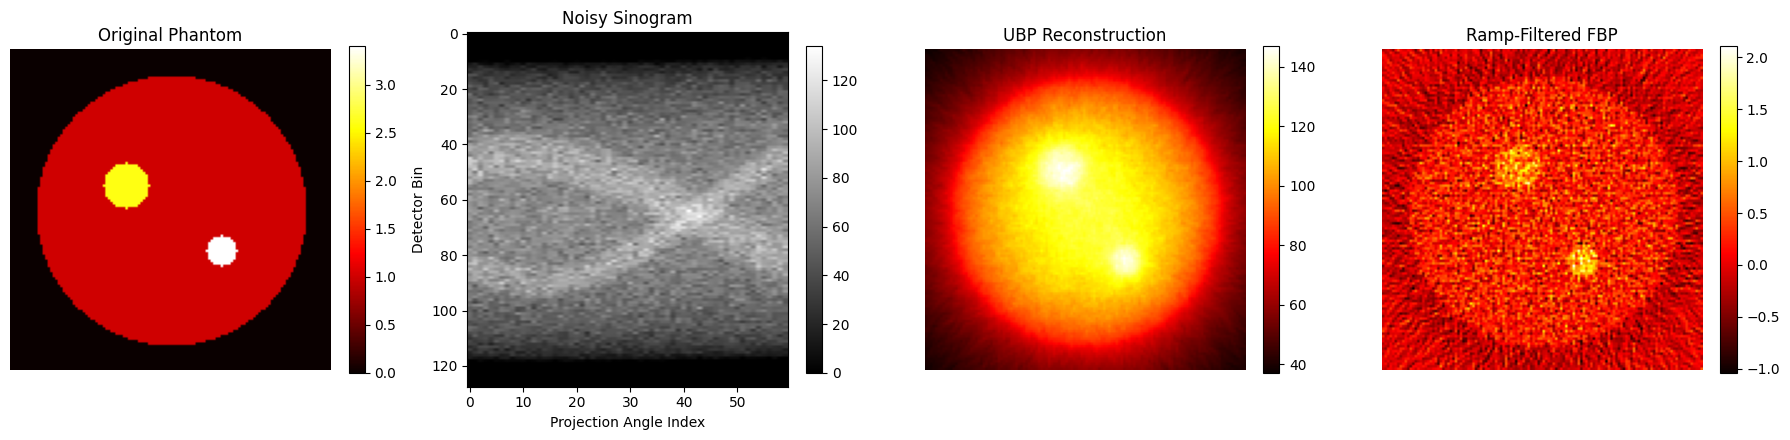

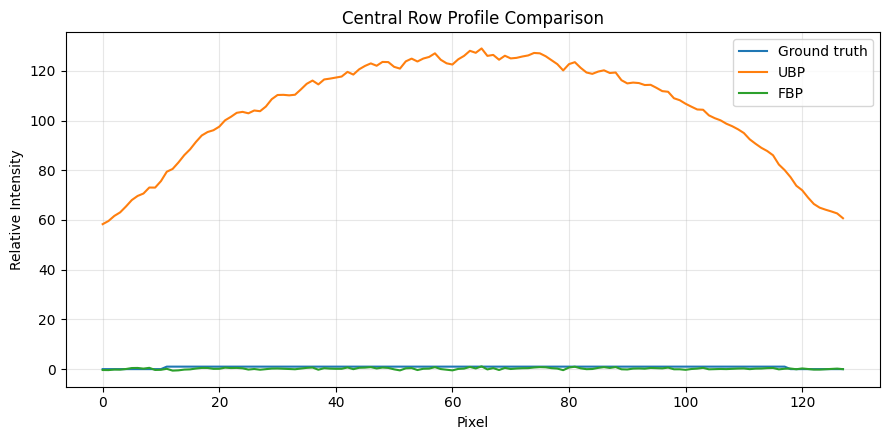


Short analysis:
- The UBP reconstruction looks blurred because simple backprojection spreads each projection across the image without compensating for the over-smearing.
- The FBP reconstruction restores sharper edges and improves visibility of the hot regions, so spatial detail is closer to the original phantom.
- UBP usually has fewer sharp streaks but strong overall blur, while FBP reduces blur at the cost of making noise and streak artifacts more apparent.
- In the noisy acquisition, FBP better separates the two hot lesions from the background, but the image texture is noisier than UBP because the ramp filter boosts high-frequency content.


In [4]:
print("=== Coding Exercise 2: PET Phantom Reconstruction ===")

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import rotate

# Suggested baseline settings (you may change these)
image_size = 128
angles_deg = np.linspace(0.0, 180.0, 60, endpoint=False)
total_counts = 400_000

# TODO 1: Create a 2D phantom with:
# - Uniform background uptake
# - At least two hot regions (different sizes and/or intensities)
yy, xx = np.mgrid[0:image_size, 0:image_size]
cx = image_size / 2
cy = image_size / 2

phantom = np.zeros((image_size, image_size), dtype=float)

body_radius = image_size * 0.42
body_mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= body_radius ** 2
phantom[body_mask] = 1.0

hot1 = (xx - (cx - 18)) ** 2 + (yy - (cy - 10)) ** 2 <= 9 ** 2
hot2 = (xx - (cx + 20)) ** 2 + (yy - (cy + 16)) ** 2 <= 6 ** 2

phantom[hot1] = 2.6
phantom[hot2] = 3.4

# TODO 2: Generate a parallel-beam sinogram over multiple projection angles. (Hint: implement a Radon-transform)
def radon_transform(image, angles):
    sinogram = []
    for angle in angles:
        rotated = rotate(image, angle, reshape=False, order=1)
        projection = np.sum(rotated, axis=0)
        sinogram.append(projection)
    return np.array(sinogram).T

sinogram = radon_transform(phantom, angles_deg)

# TODO 3: Scale the sinogram to represent total counts, then add Poisson noise.
sinogram_sum = np.sum(sinogram)
scale_factor = total_counts / sinogram_sum
expected_counts_sinogram = sinogram * scale_factor

rng = np.random.default_rng(42)
noisy_sinogram = rng.poisson(expected_counts_sinogram)

# TODO 4: Reconstruct the image using UBP and FBP.
def unfiltered_backprojection(sinogram, angles, output_size):
    reconstruction = np.zeros((output_size, output_size), dtype=float)
    detector_positions = np.arange(sinogram.shape[0]) - sinogram.shape[0] / 2
    xx, yy = np.mgrid[0:output_size, 0:output_size]
    x = xx - output_size / 2
    y = yy - output_size / 2

    for i, angle in enumerate(angles):
        theta = np.deg2rad(angle)
        s = x * np.cos(theta) + y * np.sin(theta)
        projection = sinogram[:, i]
        backprojected = np.interp(
            s.ravel(),
            detector_positions,
            projection,
            left=0.0,
            right=0.0
        ).reshape(output_size, output_size)
        reconstruction += backprojected

    reconstruction *= np.pi / (2 * len(angles))
    return reconstruction

def ramp_filter_sinogram(sinogram):
    n_detectors = sinogram.shape[0]
    freqs = np.fft.fftfreq(n_detectors)
    ramp = np.abs(freqs)

    filtered = np.zeros_like(sinogram, dtype=float)
    for i in range(sinogram.shape[1]):
        proj_fft = np.fft.fft(sinogram[:, i])
        filtered_proj_fft = proj_fft * ramp
        filtered[:, i] = np.real(np.fft.ifft(filtered_proj_fft))
    return filtered

ubp_recon = unfiltered_backprojection(noisy_sinogram, angles_deg, image_size)

filtered_sinogram = ramp_filter_sinogram(noisy_sinogram)
fbp_recon = unfiltered_backprojection(filtered_sinogram, angles_deg, image_size)

# TODO 5: Compare results to ground truth.
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

im0 = axes[0].imshow(phantom, cmap="hot")
axes[0].set_title("Original Phantom")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(noisy_sinogram, cmap="gray", aspect="auto")
axes[1].set_title("Noisy Sinogram")
axes[1].set_xlabel("Projection Angle Index")
axes[1].set_ylabel("Detector Bin")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(ubp_recon, cmap="hot")
axes[2].set_title("UBP Reconstruction")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(fbp_recon, cmap="hot")
axes[3].set_title("Ramp-Filtered FBP")
axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()

# Optional line profiles through the center to compare sharpness
center_row = image_size // 2
plt.figure(figsize=(9, 4.5))
plt.plot(phantom[center_row], label="Ground truth")
plt.plot(ubp_recon[center_row], label="UBP")
plt.plot(fbp_recon[center_row], label="FBP")
plt.title("Central Row Profile Comparison")
plt.xlabel("Pixel")
plt.ylabel("Relative Intensity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TODO 6: Write a short analysis.
print("\nShort analysis:")
print(
    "- The UBP reconstruction looks blurred because simple backprojection spreads each projection "
    "across the image without compensating for the over-smearing."
)
print(
    "- The FBP reconstruction restores sharper edges and improves visibility of the hot regions, "
    "so spatial detail is closer to the original phantom."
)
print(
    "- UBP usually has fewer sharp streaks but strong overall blur, while FBP reduces blur at the "
    "cost of making noise and streak artifacts more apparent."
)
print(
    "- In the noisy acquisition, FBP better separates the two hot lesions from the background, but "
    "the image texture is noisier than UBP because the ramp filter boosts high-frequency content."
)

## 3.2 SPECT Clinical Applications

### **Questions 9**

- a) Myocardial perfusion SPECT (MPS) uses Tc-99m sestamibi or Tl-201. Explain the mechanism by which each tracer accumulates in viable myocardium, and describe what a **reversible defect** indicates versus a **fixed defect**.

Tc-99m sestamibi accumulates in viable myocardium primarily through passive diffusion into myocardial cells and is retained within mitochondria due to the negative transmembrane potential. This uptake reflects both blood flow and cellular viability.

Tl-201 behaves as a potassium analog and is actively transported into myocardial cells via the Na⁺/K⁺ ATPase pump. Its uptake depends on intact cell membrane function and perfusion.

A reversible defect is a region that shows reduced uptake during stress but normal or improved uptake at rest, indicating ischemia where blood flow is insufficient under stress but viable myocardium is still present.

A fixed defect is a region with reduced uptake in both stress and rest images, suggesting non-viable tissue such as scar from prior infarction.

---

- b) Bone scintigraphy uses Tc-99m MDP. Explain the mechanism of skeletal uptake. Give two different clinical scenarios where tomographic SPECT acquisition provides information that a planar bone scan cannot.

Tc-99m MDP localizes to bone through chemisorption onto the surface of hydroxyapatite crystals, particularly in areas of active bone turnover and osteoblastic activity. Uptake is therefore related to both blood flow and bone remodeling.

One clinical scenario is distinguishing degenerative changes from metastatic disease in the spine, where planar imaging may show overlapping structures but SPECT can localize uptake to specific vertebral components.

Another scenario is detecting small or subtle lesions, such as stress fractures or early metastatic deposits, where SPECT improves contrast and depth localization compared to planar imaging.

---

- c) Brain perfusion SPECT uses Tc-99m HMPAO. What physiological process is being imaged, and give one clinical application where this technique contributes diagnostic information.

Brain perfusion SPECT with Tc-99m HMPAO images regional cerebral blood flow. The tracer crosses the blood-brain barrier and is trapped within brain tissue in proportion to perfusion at the time of injection.

One clinical application is the evaluation of dementia, where patterns of reduced perfusion in specific brain regions can help differentiate conditions such as Alzheimer's disease from other types of dementia.

---

- d) Give one specific clinical example where adding CT to a SPECT acquisition (SPECT/CT) changes clinical management compared to SPECT alone, and explain what the CT component contributes.

In bone imaging, SPECT/CT can be used to evaluate a focal area of increased uptake in the spine. SPECT alone may show increased activity but cannot clearly distinguish between a benign degenerative change and a malignant lesion.

The CT component provides precise anatomical detail, allowing correlation of tracer uptake with structural findings such as sclerosis, fracture, or lytic lesions. This improves diagnostic confidence and can directly influence clinical management by distinguishing benign from malignant causes of uptake.

## 3.3 Collimator Spatial Resolution Simulation

### **Coding Exercise 3**
Implement a short simulation of parallel-hole collimator spatial resolution versus depth. This exercise is a direct application of the geometric resolution formula from **Lecture 30**.

The geometric spatial resolution (FWHM) at source-to-collimator distance $z$ is:
$$R_g(z) = d \cdot \frac{l_e + z}{l_e}$$

System resolution also includes the intrinsic detector resolution:
$$R_{sys}(z) = \sqrt{R_g(z)^2 + R_{int}^2}$$

**Collimator parameters to use:**

| Collimator | Hole diameter $d$ (mm) | Effective length $l_e$ (mm) |
|---|---|---|
| LEHR (Low Energy High Resolution) | 1.5 | 24.0 |
| LEGP (Low Energy General Purpose) | 2.0 | 27.0 |
| LEUHR (Low Energy Ultra-High Resolution) | 1.0 | 32.0 |

Assume intrinsic detector resolution $R_{int} = 3.5\ \mathrm{mm}$ for all three.

Tasks:
1. Implement `geometric_resolution(d, le, z)` and `system_resolution(d, le, r_int, z)`.
2. Plot system FWHM (mm) vs depth (0–300 mm) for all three collimators.
3. Add a vertical dashed line at 100 mm (10 cm) depth (a typical cardiac imaging depth) and annotate the FWHM value for each collimator there.
4. Write 2–3 sentences interpreting which collimator you would choose for a small superficial organ versus a deep abdominal organ, and what trade-off you accept.

**Helpful Note:** Resolution degrades linearly with depth for a parallel-hole collimator. This is one of the fundamental constraints of planar and SPECT imaging that PET avoids by using electronic collimation.

=== Coding Exercise 3: Collimator Spatial Resolution vs Depth ===


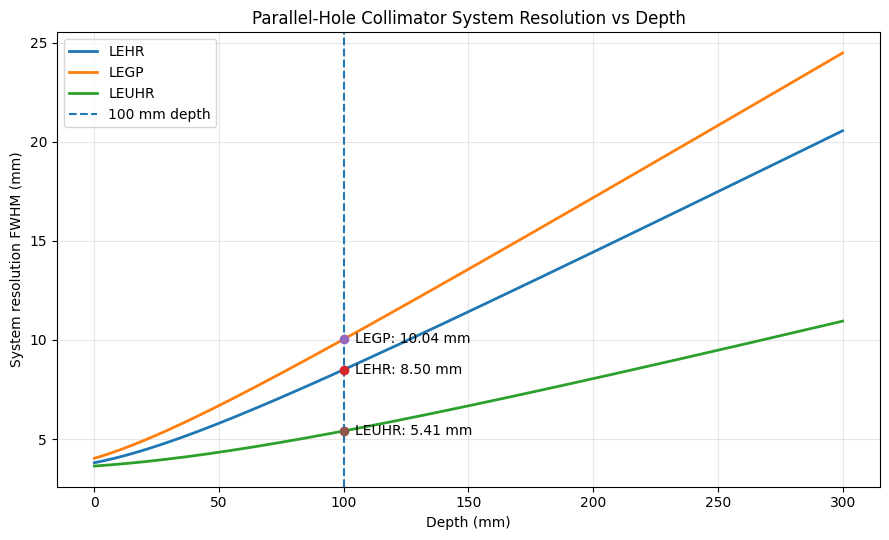


FWHM at 100 mm depth:
LEHR: 8.50 mm
LEGP: 10.04 mm
LEUHR: 5.41 mm


In [6]:
print("=== Coding Exercise 3: Collimator Spatial Resolution vs Depth ===")

import matplotlib.pyplot as plt
import numpy as np

# Given in the instructions/table
r_int_mm = 3.5
depth_mm = np.linspace(0.0, 300.0, 301)
cardiac_depth_mm = 100.0

# TODO 1: Create a collimator parameter dictionary for LEHR, LEGP, LEUHR using d (mm) and l_e (mm) from the markdown table.
collimators = {
    "LEHR": {"d_mm": 1.5, "le_mm": 24.0},
    "LEGP": {"d_mm": 2.0, "le_mm": 27.0},
    "LEUHR": {"d_mm": 1.0, "le_mm": 32.0},
}

# TODO 2: Implement geometric_resolution(d_mm, le_mm, z_mm).
def geometric_resolution(d_mm, le_mm, z_mm):
    return d_mm * (le_mm + z_mm) / le_mm

# TODO 3: Implement system_resolution(d_mm, le_mm, r_int_mm, z_mm).
def system_resolution(d_mm, le_mm, r_int_mm, z_mm):
    r_g = geometric_resolution(d_mm, le_mm, z_mm)
    return np.sqrt(r_g**2 + r_int_mm**2)

# TODO 4: Plot system FWHM vs depth for all three collimators.
plt.figure(figsize=(9, 5.5))

cardiac_values = {}

for name, params in collimators.items():
    r_sys = system_resolution(
        params["d_mm"],
        params["le_mm"],
        r_int_mm,
        depth_mm
    )
    plt.plot(depth_mm, r_sys, label=name, linewidth=2)

    cardiac_fwhm = system_resolution(
        params["d_mm"],
        params["le_mm"],
        r_int_mm,
        cardiac_depth_mm
    )
    cardiac_values[name] = cardiac_fwhm

# TODO 5: Add a vertical dashed line at 100 mm and annotate each curve's value there.
plt.axvline(cardiac_depth_mm, linestyle="--", linewidth=1.5, label="100 mm depth")

for name, value in cardiac_values.items():
    plt.plot(cardiac_depth_mm, value, marker="o")
    plt.annotate(
        f"{name}: {value:.2f} mm",
        xy=(cardiac_depth_mm, value),
        xytext=(8, 0),
        textcoords="offset points",
        va="center"
    )

# TODO 6: Add labels/title/legend and write 2–3 sentences on clinical trade-offs.
plt.xlabel("Depth (mm)")
plt.ylabel("System resolution FWHM (mm)")
plt.title("Parallel-Hole Collimator System Resolution vs Depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFWHM at 100 mm depth:")
for name, value in cardiac_values.items():
    print(f"{name}: {value:.2f} mm")



For a small superficial organ, I would choose LEUHR because it gives the best spatial resolution, which is most important when trying to visualize fine detail near the detector. For a deep abdominal organ, I would more likely choose LEGP because resolution degrades with depth for all collimators, and a general-purpose design usually accepts the trade-off of lower resolution in exchange for higher sensitivity and more practical count collection.

So the trade-off is between sharper detail and better count sensitivity: higher-resolution collimators preserve detail better but reject more photons, which can make scans noisier or require longer imaging.

---
# Part 4: Course Reflection

## Course Reflection (Approx. 1/3 page)

Write a concise reflection (about one-third of a page) that highlights your learning and experience in this course. Your response should be written as a short, well-structured paragraph or two, not point form.

In your reflection, aim to address the following ideas in a natural, integrated way:

* The most important concepts or insights you are taking away from the course and why they matter for understanding biomedical imaging
* One area where your understanding meaningfully improved, including how your thinking changed over the term
* How you developed as a problem-solver, with a specific example (e.g., quantitative reasoning, interpreting images, connecting physics to clinical use, coding, or communication)
* One aspect of the course (teaching approach, assignments, or structure) that particularly supported your learning

Focus on clarity, specificity, and reflection on your learning journey. Strong responses will connect course content to skills, understanding, and future applications.


Over the course of this class, one of the most important insights I gained is how closely physics, instrumentation, and clinical application are connected in biomedical imaging. Concepts like radioactive decay, Poisson statistics, and detector design aren't just abstract ideas; they directly determine image quality, noise, and diagnostic accuracy. Understanding things like the resolution–sensitivity trade-off in SPECT or the role of coincidence detection in PET made it much clearer how system design impacts what clinicians are actually able to see. This matters because it shifts imagig from something that simply produces images to a system that can be analyzed, optimized, and critically evaluated.

One area where my understanding improved significantly was reconstruction and image formation. At the beginning of the term, methods like backprojection or iterative reconstruction felt procedural and I had a hard time interpreting them. Over time though, while working through coding-based exercises, I began to truly grasp how projection data is transformed into images . This helped me refelct on why different reconstruction approaches lead to different noise and artifact patterns, as we've seen in class. My thought process shifted from trying to memorize steps to actually reasoning through what each method is doing, which made it much easier to interpret results and troubleshoot issues (and perform better on exams!).

I also developed as a problem-solver, particularly in how I approach complex, multi-step problems. Earlier in the course, I tended to focus on getting to an answer quickly, but over time I became more deliberate in structuring my approach by breaking problems into smaller components, clearly defining assumptions, and checking whether results made physical sense to me based off concepts we've learnt in lecture. For example, when working through simulations of decay or count statistics, I became more focused on interpreting trends rather than just computing values. I’ve become more precise in how I frame technical questions, structure problem statements, and communicate what I’m trying to solve. I now spend more time clarifying the goal, constraints, and expected output before working through a solution, which has made my overall reasoning more intentional, and ultimately more efficient.

One aspect of the course that supported my learning was the integration of theory with applied exercises. The combination of conceptual questions and hands-on implementation made it much easier to connect physics principles to real imaging scenarios. This structure not only reinforced my understanding but also helped me become more confident in applying concepts across different contexts, from theoretical questions to practical modeling and analysis. :)

Thank you for a wonderful semester, this course has been one of the most interesting from my degree! 

---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. Run all cells in order before submission.
2. **PDF Export** (`.pdf`): Export the notebook to PDF and verify that all equations, figures, and captions render correctly.

**Important:** Complete all answers directly in this notebook.

**File naming convention:** `LastName_FirstName_Deliverable5.ipynb` and `.pdf`

**Due:** Tuesday, April 14, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Coding Exercises Due |
|---------|--------------------------------|
| **Part 1: Radioactivity, Radiotracers, and Counting Fundamentals** | Q1 (a, b, c), Q2 (a, b, c), Coding Exercise 1, Q3 (a, b, c, d), Q4 (a, b, c, d) |
| **Part 2: Gamma Camera Imaging, SPECT, and Image Corrections** | Q5 (a, b, c, d), Q6 (a, b, c, d) |
| **Part 3: PET Physics and Imaging Systems** | Q7 (a, b, c), Q8 (a, b, c), Coding Exercise 2, Q9 (a, b, c, d), Coding Exercise 3 |
| **Part 4: Course Reflection** | Written reflection (~1/3 page) |